# Description

Here I do the same as the previous notebook, but with the GLS model proposed in PhenoPLIER.

# Modules

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.graphics.gofplots import qqplot_2samples
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

import conf
from data.recount2 import LVAnalysis
from phenoplier_plots import qqplot

# Settings

In [2]:
N_PHENOTYPES = 1000
N_LVS = 987

In [3]:
INPUT_DIR = (
    conf.RESULTS["GLS_NULL_SIMS"]
    / "phenoplier"
    / "ukbb_eur"
    / "covars"
    # / "_corrs_5mb"
    / "gls-gtex_v8_mashr-sub_corr"
)
display(INPUT_DIR)
assert INPUT_DIR.exists()

PosixPath('/home/miltondp/projects/phenoplier/clean_orig_base/phenoplier-gwas-40pcs/results/gls/null_sims/phenoplier/ukbb_eur/covars/gls-gtex_v8_mashr-sub_corr')

In [4]:
OUTPUT_DIR = conf.RESULTS["GLS_NULL_SIMS"]
display(OUTPUT_DIR)

PosixPath('/home/miltondp/projects/phenoplier/clean_orig_base/phenoplier-gwas-40pcs/results/gls/null_sims')

In [5]:
PVALUE_COLUMN = "pvalue_onesided"

# Load MultiXcan genes present in results

In [6]:
_tmp = pd.read_csv(
    conf.RESULTS["GLS_NULL_SIMS"]
    / "twas"
    / "smultixcan"
    / "random.pheno0-gtex_v8-mashr-smultixcan.txt",
    sep="\t",
)

In [7]:
_tmp.shape

(22519, 18)

In [8]:
_tmp.head()

,gene,gene_name,pvalue,n,n_indep,p_i_best,t_i_best,p_i_worst,t_i_worst,eigen_max,eigen_min,eigen_min_kept,z_min,z_max,z_mean,z_sd,tmi,status
0,ENSG00000254416.5,RP11-347E10.1,0.000017,4.0,3.0,0.024445,Spleen,0.262916,Nerve_Tibial,2.612788,1.693280e-02,0.340580,-1.311768,2.250056,0.261960,1.758121,3.0,0
1,ENSG00000271564.1,RP13-444H2.1,0.000300,1.0,1.0,0.000300,Testis,0.000300,Testis,1.000000,1.000000e+00,1.000000,-3.615233,-3.615233,-3.615233,NaN,1.0,0
2,ENSG00000181788.3,SIAH2,0.000467,45.0,1.0,0.000042,Muscle_Skeletal,0.017281,Thyroid,43.177415,9.963391e-16,43.177415,-4.094931,3.722543,-1.477930,3.180245,1.0,0
3,ENSG00000168830.7,HTR1E,0.000522,18.0,3.0,0.000067,Thyroid,0.384080,Brain_Hippocampus,9.555565,7.385609e-18,1.151398,-3.780852,3.988471,0.638196,1.955544,3.0,0
4,ENSG00000148734.7,NPFFR1,0.000618,22.0,6.0,0.005663,Brain_Hippocampus,0.973529,Nerve_Tibial,11.780344,6.448113e-18,0.520242,-2.766662,2.766662,-0.709423,1.916941,6.0,0


In [9]:
multixcan_genes = set(_tmp["gene_name"])
display(len(multixcan_genes))
display(list(multixcan_genes)[:10])

22512

['OAS1',
 'SPRR2F',
 'IGF2BP2',
 'TMEM260',
 'GLS',
 'CAPS2',
 'PPFIBP1',
 'FGF19',
 'NT5DC3',
 'RP11-701H24.3']

# Load MultiPLIER Z matrix

In [10]:
multiplier_z = pd.read_pickle(conf.MULTIPLIER["MODEL_Z_MATRIX_FILE"])

In [11]:
multiplier_z.shape

(6750, 987)

In [12]:
# keep genes only present in MultiXcan
multiplier_z = multiplier_z.loc[
    sorted(multixcan_genes.intersection(multiplier_z.index))
]

In [13]:
multiplier_z.shape

(6453, 987)

In [14]:
multiplier_z.head()

,LV1,LV2,LV3,LV4,LV5,LV6,LV7,LV8,LV9,LV10,...,LV978,LV979,LV980,LV981,LV982,LV983,LV984,LV985,LV986,LV987
A2M,0.000000,0.000000,0.000000,0.078428,0.0,0.00000,0.000000,0.046772,0.000000,0.011033,...,0.010910,0.000000,0.052869,0.012749,0.0,0.013982,0.152241,0.000000,0.000000,0.108884
AAAS,0.271162,0.000000,0.000000,0.000000,0.0,0.00000,0.000000,0.000000,1.513337,0.000000,...,0.000000,0.000000,0.000000,0.001385,0.0,0.000000,0.711896,0.030534,0.447105,0.424685
AANAT,0.005099,0.308497,0.028815,0.000000,0.0,0.00000,0.371725,0.000000,0.135238,0.000000,...,0.117163,0.018815,0.000000,0.193142,0.0,0.040401,0.180436,0.000000,0.000000,0.042064
AARS,0.512978,0.000000,0.451285,0.319568,0.0,0.00000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.006208,0.021274,0.0,0.000000,0.062143,0.000000,0.000000,0.364892
AARS2,1.008157,0.000000,0.197424,0.024832,0.0,0.57081,0.000000,0.228675,0.000000,0.116243,...,0.000000,0.000000,0.153345,0.000000,0.0,0.000000,1.004578,0.014470,0.000000,0.000000


# Functions

In [15]:
def show_prop(data, frac=0.05):
    pvalues = data[PVALUE_COLUMN]
    return get_prop(pvalues, frac=frac)

In [16]:
def get_prop(pvalues, frac=0.05):
    _pvalue_lt_frac = pvalues[pvalues < frac]
    return _pvalue_lt_frac.shape[0] / pvalues.shape[0]

In [17]:
assert get_prop(np.array([0.20, 0.50]), 0.05) == 0.0
assert get_prop(np.array([0.20, 0.50, 0.75, 0.10, 0.04]), 0.05) == 0.2

In [18]:
assert get_prop(pd.Series(np.array([0.20, 0.50])), 0.05) == 0.0
assert get_prop(pd.Series(np.array([0.20, 0.50, 0.75, 0.10, 0.04])), 0.05) == 0.2

In [19]:
def get_lv_genes(lv_code):
    lv_genes = multiplier_z[lv_code].sort_values(ascending=False)
    lv_obj = LVAnalysis(lv_code)
    return lv_obj.lv_genes.set_index("gene_name").loc[lv_genes.index]

# Get files list

In [20]:
INPUT_FILES = list(INPUT_DIR.glob("*.tsv.gz"))
display(INPUT_FILES[:5])

[PosixPath('/home/miltondp/projects/phenoplier/clean_orig_base/phenoplier-gwas-40pcs/results/gls/null_sims/phenoplier/ukbb_eur/covars/gls-gtex_v8_mashr-sub_corr/random.pheno2-gls_phenoplier.tsv.gz'),
 PosixPath('/home/miltondp/projects/phenoplier/clean_orig_base/phenoplier-gwas-40pcs/results/gls/null_sims/phenoplier/ukbb_eur/covars/gls-gtex_v8_mashr-sub_corr/random.pheno0-gls_phenoplier.tsv.gz'),
 PosixPath('/home/miltondp/projects/phenoplier/clean_orig_base/phenoplier-gwas-40pcs/results/gls/null_sims/phenoplier/ukbb_eur/covars/gls-gtex_v8_mashr-sub_corr/random.pheno4-gls_phenoplier.tsv.gz'),
 PosixPath('/home/miltondp/projects/phenoplier/clean_orig_base/phenoplier-gwas-40pcs/results/gls/null_sims/phenoplier/ukbb_eur/covars/gls-gtex_v8_mashr-sub_corr/random.pheno1-gls_phenoplier.tsv.gz'),
 PosixPath('/home/miltondp/projects/phenoplier/clean_orig_base/phenoplier-gwas-40pcs/results/gls/null_sims/phenoplier/ukbb_eur/covars/gls-gtex_v8_mashr-sub_corr/random.pheno3-gls_phenoplier.tsv.gz')]

# Load data

In [21]:
dfs = [
    pd.read_csv(f, sep="\t").assign(phenotype=f.name.split("-")[0]) for f in INPUT_FILES
]

In [22]:
display(len(dfs))
assert len(dfs) == N_PHENOTYPES

5

AssertionError: 

In [23]:
dfs = pd.concat(dfs, axis=0, ignore_index=True)

In [24]:
display(dfs.shape)
assert dfs.shape[0] == N_PHENOTYPES * N_LVS

(4935, 7)

AssertionError: 

In [25]:
dfs.head()

,lv,beta,beta_se,t,pvalue_twosided,pvalue_onesided,phenotype
0,LV208,0.379500,0.125047,3.034855,0.002416,0.001208,random.pheno2
1,LV136,0.343076,0.125945,2.724022,0.006467,0.003233,random.pheno2
2,LV664,0.338838,0.126194,2.685044,0.007271,0.003635,random.pheno2
3,LV946,0.327671,0.125237,2.616406,0.008907,0.004453,random.pheno2
4,LV54,0.324059,0.126227,2.567278,0.010272,0.005136,random.pheno2


In [26]:
_tmp = dfs.groupby("phenotype")["lv"].nunique().unique()
assert _tmp.shape[0] == 1
assert _tmp[0] == N_LVS

# Mean type I error

In [27]:
_mt1e = show_prop(dfs)
display(_mt1e)

0.05714285714285714

# QQ-plot

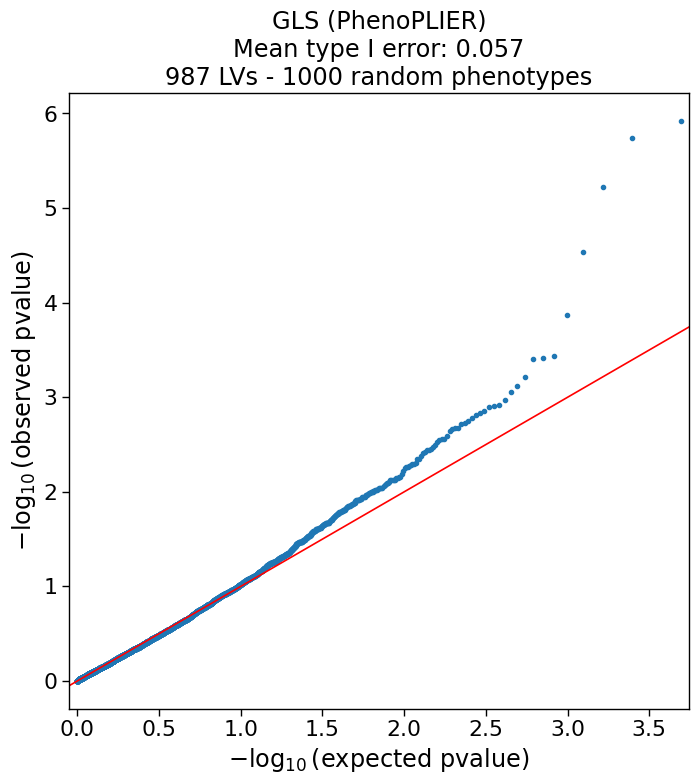

In [28]:
with sns.plotting_context("paper", font_scale=1.8), mpl.rc_context(
    {"lines.markersize": 3}
):
    fig, ax = qqplot(dfs[PVALUE_COLUMN])
    ax.set_title(
        f"GLS (PhenoPLIER)\nMean type I error: {_mt1e:.3f}\n{N_LVS} LVs - {N_PHENOTYPES} random phenotypes"
    )

# Summary of mean type I error per LV

In [31]:
summary_list = []
for lv, lv_data in dfs.groupby("lv"):
    # assert lv_data.shape[0] == N_PHENOTYPES

    summary_list.append(
        {
            "lv": lv,
            "1": get_prop(lv_data[PVALUE_COLUMN], 0.01),
            "5": get_prop(lv_data[PVALUE_COLUMN], 0.05),
            "10": get_prop(lv_data[PVALUE_COLUMN], 0.10),
        }
    )

summary_df = pd.DataFrame(summary_list)
assert summary_df.shape[0] == N_LVS

In [32]:
summary_df.shape

(987, 4)

In [33]:
summary_df.head()

,lv,1,5,10
0,LV1,0.0,0.0,0.0
1,LV10,0.0,0.2,0.2
2,LV100,0.0,0.0,0.0
3,LV101,0.0,0.2,0.2
4,LV102,0.0,0.0,0.0


In [34]:
summary_df.describe()

,1,5,10
count,987.000000,987.000000,987.000000
mean,0.015603,0.057143,0.103749
std,0.055888,0.102984,0.133361
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000
75%,0.000000,0.200000,0.200000
max,0.400000,0.600000,0.600000


## LVs with expected type I error

In [36]:
lvs_expected_error = summary_df[summary_df["5"].between(0.04, 0.06)]
display(lvs_expected_error.shape)
display(lvs_expected_error.sort_values("5").head(20))
display(lvs_expected_error.sort_values("5").tail(20))

(0, 4)

,lv,1,5,10


,lv,1,5,10


## LVs with high type I error

In [37]:
lvs_high_error = summary_df[summary_df["5"] > 0.06]
display(lvs_high_error.shape)
# display(lvs_high_error.sort_values("5").head(20))
display(lvs_high_error.sort_values("5").tail(20))

(253, 4)

,lv,1,5,10
956,LV960,0.2,0.4,0.4
10,LV108,0.2,0.4,0.4
696,LV726,0.0,0.4,0.4
930,LV937,0.2,0.4,0.4
821,LV839,0.0,0.4,0.4
923,LV930,0.0,0.4,0.4
782,LV803,0.0,0.4,0.4
707,LV736,0.2,0.4,0.6
33,LV129,0.0,0.4,0.4
138,LV223,0.4,0.4,0.4


## Save

In [ ]:
summary_df[summary_df["5"] > 0.07]

In [ ]:
summary_df.to_pickle(OUTPUT_DIR / "lvs-null_sims-1000g_eur-prop_type_I_errors.pkl")

# Query specific LVs

In [ ]:
summary_df[summary_df["lv"].isin(("LV246", "LV603"))]

## LV246

In [ ]:
lv_code = "LV246"

In [ ]:
results = dfs[dfs["lv"] == lv_code]

In [ ]:
results.shape

In [ ]:
results.head()

### Mean type I errors at different thresholds

In [ ]:
show_prop(results, 0.01)

In [ ]:
_mt1e = show_prop(results, 0.05)
display(_mt1e)

In [ ]:
show_prop(results, 0.10)

In [ ]:
show_prop(results, 0.15)

In [ ]:
show_prop(results, 0.20)

### QQplot

In [ ]:
with sns.plotting_context("paper", font_scale=1.8), mpl.rc_context(
    {"lines.markersize": 3}
):
    fig, ax = qqplot(results[PVALUE_COLUMN])
    ax.set_title(
        f"GLS model (PhenoPLIER) - {lv_code}\nMean type I error: {_mt1e:.3f}\n{results.shape[0]} random phenotypes"
    )

# Comparison with OLS model

## LVs with high mean type I error in OLS model

Here I compare the OLS's high mean type I error LVs with results from the GLS model.

### LV234

In [ ]:
lv_code = "LV234"

In [ ]:
results = dfs[dfs["lv"] == lv_code]

In [ ]:
results.shape

In [ ]:
results.head()

#### Mean type I errors at different thresholds

In [ ]:
show_prop(results, 0.01)

In [ ]:
_mt1e = show_prop(results, 0.05)
display(_mt1e)

In [ ]:
show_prop(results, 0.10)

In [ ]:
show_prop(results, 0.15)

In [ ]:
show_prop(results, 0.20)

#### QQplot

In [ ]:
with sns.plotting_context("paper", font_scale=1.8), mpl.rc_context(
    {"lines.markersize": 3}
):
    fig, ax = qqplot(results[PVALUE_COLUMN])
    ax.set_title(
        f"GLS model (PhenoPLIER) - {lv_code}\nMean type I error: {_mt1e:.3f}\n{results.shape[0]} random phenotypes"
    )

#### Top genes in LV

In [ ]:
lv_genes = get_lv_genes(lv_code)
display(lv_genes.head(25))

In [ ]:
# see bands of top genes
lv_genes.head(68)["gene_band"].value_counts().head(10)

### LV847

In [ ]:
lv_code = "LV847"

In [ ]:
results = dfs[dfs["lv"] == lv_code]

In [ ]:
results.shape

In [ ]:
results.head()

#### Mean type I errors at different thresholds

In [ ]:
show_prop(results, 0.01)

In [ ]:
_mt1e = show_prop(results, 0.05)
display(_mt1e)

In [ ]:
show_prop(results, 0.10)

In [ ]:
show_prop(results, 0.15)

In [ ]:
show_prop(results, 0.20)

#### QQplot

In [ ]:
with sns.plotting_context("paper", font_scale=1.8), mpl.rc_context(
    {"lines.markersize": 3}
):
    fig, ax = qqplot(results[PVALUE_COLUMN])
    ax.set_title(
        f"GLS model (PhenoPLIER) - {lv_code}\nMean type I error: {_mt1e:.3f}\n{results.shape[0]} random phenotypes"
    )

#### Top genes in LV

In [ ]:
lv_genes = get_lv_genes(lv_code)
display(lv_genes.head(25))

In [ ]:
# see bands of top genes
lv_genes.head(68)["gene_band"].value_counts().head(10)

### LV45

In [ ]:
lv_code = "LV45"

In [ ]:
results = dfs[dfs["lv"] == lv_code]

In [ ]:
results.shape

In [ ]:
results.head()

#### Mean type I errors at different thresholds

In [ ]:
show_prop(results, 0.01)

In [ ]:
_mt1e = show_prop(results, 0.05)
display(_mt1e)

In [ ]:
show_prop(results, 0.10)

In [ ]:
show_prop(results, 0.15)

In [ ]:
show_prop(results, 0.20)

#### QQplot

In [ ]:
with sns.plotting_context("paper", font_scale=1.8), mpl.rc_context(
    {"lines.markersize": 3}
):
    fig, ax = qqplot(results[PVALUE_COLUMN])
    ax.set_title(
        f"GLS model (PhenoPLIER) - {lv_code}\nMean type I error: {_mt1e:.3f}\n{results.shape[0]} random phenotypes"
    )

#### Top genes in LV

In [ ]:
lv_genes = get_lv_genes(lv_code)
display(lv_genes.head(25))

In [ ]:
# see bands of top genes
lv_genes.head(68)["gene_band"].value_counts().head(10)

### LV800

In [ ]:
lv_code = "LV800"

In [ ]:
results = dfs[dfs["lv"] == lv_code]

In [ ]:
results.shape

In [ ]:
results.head()

#### Mean type I errors at different thresholds

In [ ]:
show_prop(results, 0.01)

In [ ]:
_mt1e = show_prop(results, 0.05)
display(_mt1e)

In [ ]:
show_prop(results, 0.10)

In [ ]:
show_prop(results, 0.15)

In [ ]:
show_prop(results, 0.20)

#### QQplot

In [ ]:
with sns.plotting_context("paper", font_scale=1.8), mpl.rc_context(
    {"lines.markersize": 3}
):
    fig, ax = qqplot(results[PVALUE_COLUMN])
    ax.set_title(
        f"GLS model (PhenoPLIER) - {lv_code}\nMean type I error: {_mt1e:.3f}\n{results.shape[0]} random phenotypes"
    )

#### Top genes in LV

In [ ]:
lv_genes = get_lv_genes(lv_code)
display(lv_genes.head(25))

In [ ]:
# see bands of top genes
lv_genes.head(68)["gene_band"].value_counts().head(10)

### LV914

This one is not corrected here, I analyze it below.

### LV189

In [ ]:
lv_code = "LV189"

In [ ]:
results = dfs[dfs["lv"] == lv_code]

In [ ]:
results.shape

In [ ]:
results.head()

#### Mean type I errors at different thresholds

In [ ]:
show_prop(results, 0.01)

In [ ]:
_mt1e = show_prop(results, 0.05)
display(_mt1e)

In [ ]:
show_prop(results, 0.10)

In [ ]:
show_prop(results, 0.15)

In [ ]:
show_prop(results, 0.20)

#### QQplot

In [ ]:
with sns.plotting_context("paper", font_scale=1.8), mpl.rc_context(
    {"lines.markersize": 3}
):
    fig, ax = qqplot(results[PVALUE_COLUMN])
    ax.set_title(
        f"GLS model (PhenoPLIER) - {lv_code}\nMean type I error: {_mt1e:.3f}\n{results.shape[0]} random phenotypes"
    )

#### Top genes in LV

In [ ]:
lv_genes = get_lv_genes(lv_code)
display(lv_genes.head(25))

In [ ]:
# see bands of top genes
lv_genes.head(68)["gene_band"].value_counts().head(10)

## LVs with expected mean type I error

Here I make sure the well calibrated LVs in the OLS model are still well calibrated here.

In [ ]:
display(lvs_expected_error.sort_values("5").head(20))

Here I'm manually selecting from this list, since I want those that are well calibrated across different p-value thresholds.

### LV924

In [ ]:
lv_code = "LV924"

In [ ]:
results = dfs[dfs["lv"] == lv_code]

In [ ]:
results.shape

In [ ]:
results.head()

#### Mean type I errors at different thresholds

In [ ]:
show_prop(results, 0.01)

In [ ]:
_mt1e = show_prop(results, 0.05)
display(_mt1e)

In [ ]:
show_prop(results, 0.10)

In [ ]:
show_prop(results, 0.15)

In [ ]:
show_prop(results, 0.20)

#### QQplot

In [ ]:
with sns.plotting_context("paper", font_scale=1.8), mpl.rc_context(
    {"lines.markersize": 3}
):
    fig, ax = qqplot(results[PVALUE_COLUMN])
    ax.set_title(
        f"GLS model (PhenoPLIER) - {lv_code}\nMean type I error: {_mt1e:.3f}\n{results.shape[0]} random phenotypes"
    )

Hm, well calibrated in general, but with one small pvalue.

### LV675

In [ ]:
lv_code = "LV675"

In [ ]:
results = dfs[dfs["lv"] == lv_code]

In [ ]:
results.shape

In [ ]:
results.head()

#### Mean type I errors at different thresholds

In [ ]:
show_prop(results, 0.01)

In [ ]:
_mt1e = show_prop(results, 0.05)
display(_mt1e)

In [ ]:
show_prop(results, 0.10)

In [ ]:
show_prop(results, 0.15)

In [ ]:
show_prop(results, 0.20)

#### QQplot

In [ ]:
with sns.plotting_context("paper", font_scale=1.8), mpl.rc_context(
    {"lines.markersize": 3}
):
    fig, ax = qqplot(results[PVALUE_COLUMN])
    ax.set_title(
        f"GLS model (PhenoPLIER) - {lv_code}\nMean type I error: {_mt1e:.3f}\n{results.shape[0]} random phenotypes"
    )

### LV691

In [ ]:
lv_code = "LV691"

In [ ]:
results = dfs[dfs["lv"] == lv_code]

In [ ]:
results.shape

In [ ]:
results.head()

#### Mean type I errors at different thresholds

In [ ]:
show_prop(results, 0.01)

In [ ]:
_mt1e = show_prop(results, 0.05)
display(_mt1e)

In [ ]:
show_prop(results, 0.10)

In [ ]:
show_prop(results, 0.15)

In [ ]:
show_prop(results, 0.20)

#### QQplot

In [ ]:
with sns.plotting_context("paper", font_scale=1.8), mpl.rc_context(
    {"lines.markersize": 3}
):
    fig, ax = qqplot(results[PVALUE_COLUMN])
    ax.set_title(
        f"GLS model (PhenoPLIER) - {lv_code}\nMean type I error: {_mt1e:.3f}\n{results.shape[0]} random phenotypes"
    )

# GLS model - LVs with high mean type I error

## LV914

In [ ]:
lv_code = "LV914"

In [ ]:
results = dfs[dfs["lv"] == lv_code]

In [ ]:
results.shape

In [ ]:
results.head()

### Mean type I errors at different thresholds

In [ ]:
show_prop(results, 0.01)

In [ ]:
_mt1e = show_prop(results, 0.05)
display(_mt1e)

In [ ]:
show_prop(results, 0.10)

In [ ]:
show_prop(results, 0.15)

In [ ]:
show_prop(results, 0.20)

### QQplot

In [ ]:
with sns.plotting_context("paper", font_scale=1.8), mpl.rc_context(
    {"lines.markersize": 3}
):
    fig, ax = qqplot(results[PVALUE_COLUMN])
    ax.set_title(
        f"GLS model (PhenoPLIER) - {lv_code}\nMean type I error: {_mt1e:.3f}\n{results.shape[0]} random phenotypes"
    )

### Top genes in LV

In [ ]:
lv_genes = get_lv_genes(lv_code)
display(lv_genes.head(25))

In [ ]:
# see bands of top genes
lv_genes.head(68)["gene_band"].value_counts().head(10)

## LV816

In [ ]:
lv_code = "LV816"

In [ ]:
results = dfs[dfs["lv"] == lv_code]

In [ ]:
results.shape

In [ ]:
results.head()

### Mean type I errors at different thresholds

In [ ]:
show_prop(results, 0.01)

In [ ]:
_mt1e = show_prop(results, 0.05)
display(_mt1e)

In [ ]:
show_prop(results, 0.10)

In [ ]:
show_prop(results, 0.15)

In [ ]:
show_prop(results, 0.20)

### QQplot

In [ ]:
with sns.plotting_context("paper", font_scale=1.8), mpl.rc_context(
    {"lines.markersize": 3}
):
    fig, ax = qqplot(results[PVALUE_COLUMN])
    ax.set_title(
        f"GLS model (PhenoPLIER) - {lv_code}\nMean type I error: {_mt1e:.3f}\n{results.shape[0]} random phenotypes"
    )

### Top genes in LV

In [ ]:
lv_genes = get_lv_genes(lv_code)
display(lv_genes.head(25))

In [ ]:
# see bands of top genes
lv_genes.head(68)["gene_band"].value_counts().head(10)

## LV588

In [ ]:
lv_code = "LV588"

In [ ]:
results = dfs[dfs["lv"] == lv_code]

In [ ]:
results.shape

In [ ]:
results.head()

### Mean type I errors at different thresholds

In [ ]:
show_prop(results, 0.01)

In [ ]:
_mt1e = show_prop(results, 0.05)
display(_mt1e)

In [ ]:
show_prop(results, 0.10)

In [ ]:
show_prop(results, 0.15)

In [ ]:
show_prop(results, 0.20)

### QQplot

In [ ]:
with sns.plotting_context("paper", font_scale=1.8), mpl.rc_context(
    {"lines.markersize": 3}
):
    fig, ax = qqplot(results[PVALUE_COLUMN])
    ax.set_title(
        f"GLS model (PhenoPLIER) - {lv_code}\nMean type I error: {_mt1e:.3f}\n{results.shape[0]} random phenotypes"
    )

### Top genes in LV

In [ ]:
lv_genes = get_lv_genes(lv_code)
display(lv_genes.head(25))

In [ ]:
# see bands of top genes
lv_genes.head(68)["gene_band"].value_counts().head(10)

# Conclusions

The GLS model is definitely an improvement over the OLS model:

* It corrects LVs with top genes from the same band, like LV234, LV847, LV45.
* There is a small improvement on mean type I error (0.0584 vs 0.0557).

However, it does not fix other problematic LVs, like LV914.